In [36]:
# Transport Demand Prediction

In [37]:
## Problem Statement
##To predict the number of seats sold for each bus ride based on available features.

In [38]:
## Data Loading

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
train_revised = pd.read_csv("train_revised.csv")

In [41]:
# Display the first few rows and the data types
print("First 5 rows of the dataframe:")
display(train_revised.head())

print("\nData types and non-null values:")
display(train_revised.info())

First 5 rows of the dataframe:


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51645 entries, 0 to 51644
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ride_id          51645 non-null  int64 
 1   seat_number      51645 non-null  object
 2   payment_method   51645 non-null  object
 3   payment_receipt  51645 non-null  object
 4   travel_date      51645 non-null  object
 5   travel_time      51645 non-null  object
 6   travel_from      51645 non-null  object
 7   travel_to        51645 non-null  object
 8   car_type         51645 non-null  object
 9   max_capacity     51645 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 3.9+ MB


None

In [42]:
## Data Cleaning

In [43]:
# Check for missing values
print("\nMissing values per column:")
display(train_revised.isnull().sum())


Missing values per column:


,0
ride_id,0
seat_number,0
payment_method,0
payment_receipt,0
travel_date,0
travel_time,0
travel_from,0
travel_to,0
car_type,0
max_capacity,0


In [44]:
# Get descriptive statistics
print("\nDescriptive statistics:")
display(train_revised.describe())


Descriptive statistics:


,ride_id,max_capacity
count,51645.000000,51645.000000
mean,10188.645793,34.534321
std,2211.295708,18.451193
min,1442.000000,11.000000
25%,8287.000000,11.000000
50%,10353.000000,49.000000
75%,12029.000000,49.000000
max,20117.000000,49.000000


In [45]:
## Data Cleaning

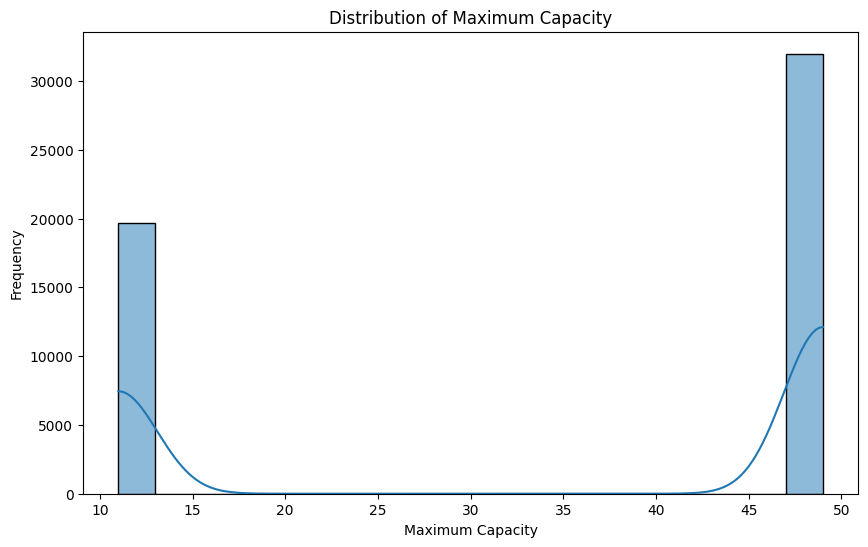

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(train_revised['max_capacity'], kde=True)
plt.title('Distribution of Maximum Capacity')
plt.xlabel('Maximum Capacity')
plt.ylabel('Frequency')
plt.show()

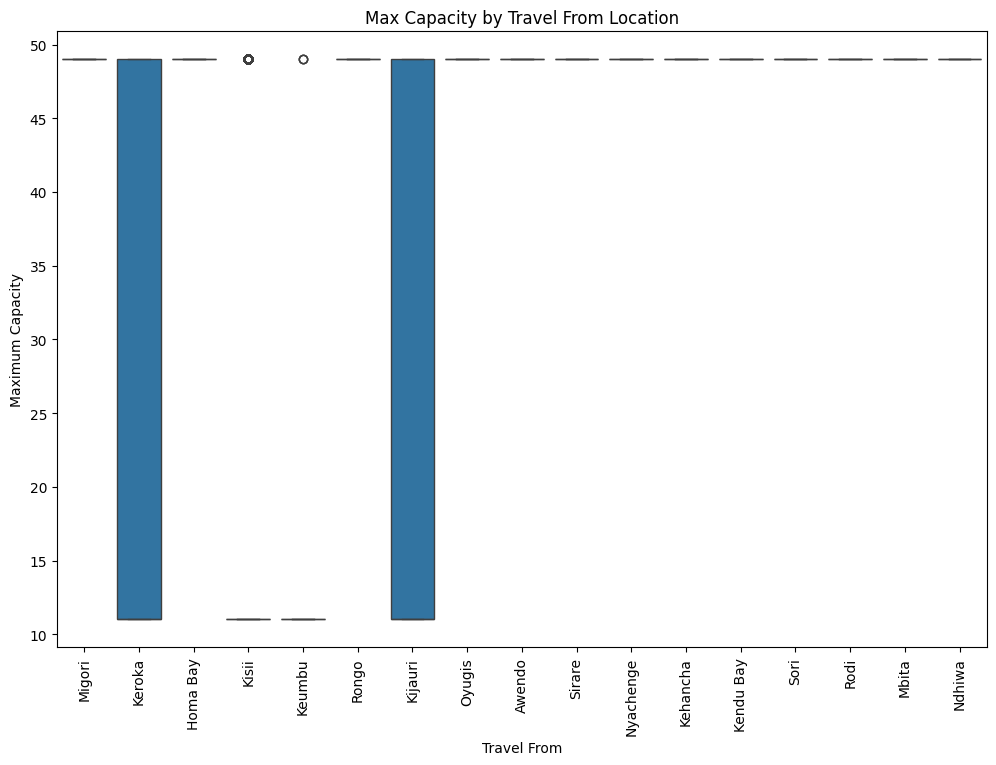

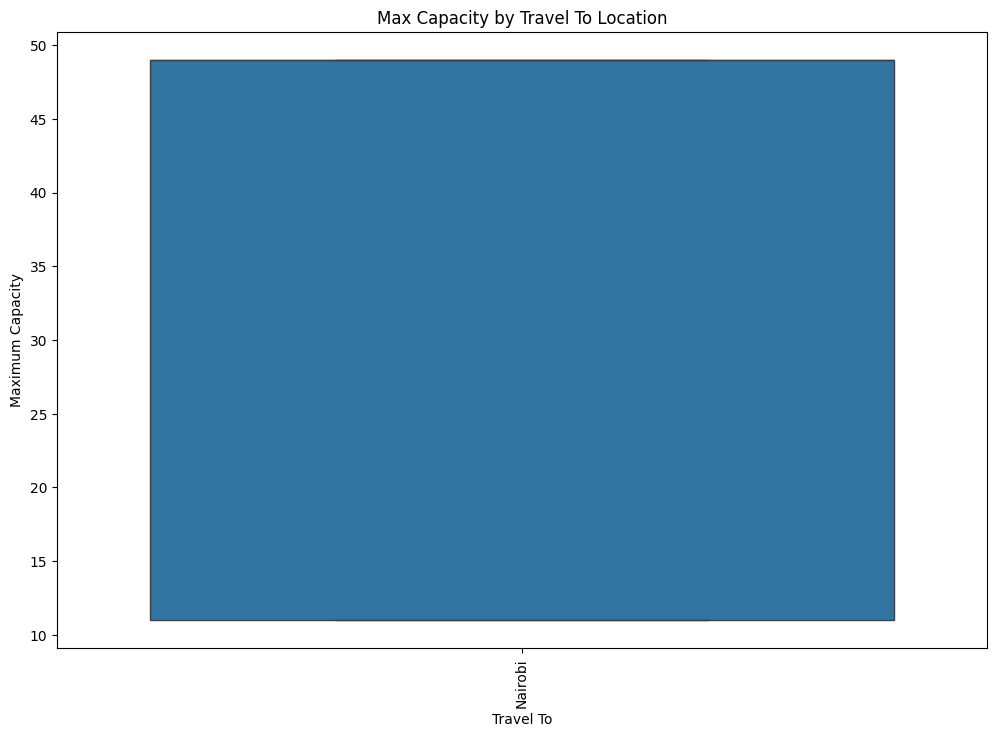

In [47]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='travel_from', y='max_capacity', data=train_revised)
plt.title('Max Capacity by Travel From Location')
plt.xlabel('Travel From')
plt.ylabel('Maximum Capacity')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='travel_to', y='max_capacity', data=train_revised)
plt.title('Max Capacity by Travel To Location')
plt.xlabel('Travel To')
plt.ylabel('Maximum Capacity')
plt.xticks(rotation=90)
plt.show()

In [48]:
train_revised['travel_time'] = train_revised['travel_time'].replace(".",":")

In [49]:
train_revised['travel_time'] = train_revised['travel_time']+ ":00"


In [50]:
train_revised.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15:00,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12:00,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05:00,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10:00,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12:00,Migori,Nairobi,Bus,49


In [51]:
## Feature Engineering

In [52]:
# Combine 'travel_date' and 'travel_time' into a single datetime column
train_revised['travel_datetime'] = pd.to_datetime(
    train_revised['travel_date'].astype(str) + ' ' + train_revised['travel_time'].astype(str),
    format='%d-%m-%y %H:%M:%S'
)
# Display the updated dataframe info to check the new column and data types
display(train_revised.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51645 entries, 0 to 51644
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ride_id          51645 non-null  int64         
 1   seat_number      51645 non-null  object        
 2   payment_method   51645 non-null  object        
 3   payment_receipt  51645 non-null  object        
 4   travel_date      51645 non-null  object        
 5   travel_time      51645 non-null  object        
 6   travel_from      51645 non-null  object        
 7   travel_to        51645 non-null  object        
 8   car_type         51645 non-null  object        
 9   max_capacity     51645 non-null  int64         
 10  travel_datetime  51645 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 4.3+ MB


None

In [53]:
# Calculate the number of seats sold per ride
seats_sold = train_revised.groupby('ride_id').size().reset_index(name='number_of_seats_sold')

# Display the first few rows of the new dataframe
display(seats_sold.head())

,ride_id,number_of_seats_sold
0,1442,1
1,5437,1
2,5710,1
3,5777,5
4,5778,31


In [54]:
# Calculate the number of seats sold per ride
seats_sold = train_revised.groupby('ride_id').size().reset_index(name='number_of_seats_sold')

# Display the first few rows of the new dataframe
display(seats_sold.head())

,ride_id,number_of_seats_sold
0,1442,1
1,5437,1
2,5710,1
3,5777,5
4,5778,31


In [55]:
train_revised.columns


Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity', 'travel_datetime'],
      dtype='object')

In [56]:
# Group by ride_id and other ride-level features
ride_sales = train_revised.groupby([
    'ride_id', 'travel_datetime', 'max_capacity'
]).agg(
    seats_sold=('seat_number', 'count')  # Count how many seats were sold
).reset_index()

In [57]:
ride_sales['day_of_week'] = ride_sales['travel_datetime'].dt.dayofweek  # 0=Monday
ride_sales['hour'] = ride_sales['travel_datetime'].dt.hour

In [58]:
ride_sales.head()

,ride_id,travel_datetime,max_capacity,seats_sold,day_of_week,hour
0,1442,2017-10-17 07:15:00,49,1,1,7
1,5437,2017-11-19 07:12:00,49,1,6,7
2,5710,2017-11-26 07:05:00,49,1,6,7
3,5777,2017-11-27 07:10:00,49,5,0,7
4,5778,2017-11-27 07:12:00,49,31,0,7


In [59]:
ride_sales.columns

Index(['ride_id', 'travel_datetime', 'max_capacity', 'seats_sold',
       'day_of_week', 'hour'],
      dtype='object')

In [60]:
feature_cols = ['max_capacity', 'day_of_week', 'hour']
target_col= 'seats_sold'
X = ride_sales[feature_cols]
y = ride_sales[target_col]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
poly = PolynomialFeatures(degree=4)    # trying different degrees until I get good results
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [64]:
model = LinearRegression()
model.fit(X_train_poly,y_train)

LinearRegression()

In [65]:
## Model Evaluation
#The model performance is evaluated using metrics such as Mean Squared Error and R² score.

In [66]:
y_pred = model.predict(X_test_poly)

print(r2_score(y_test,y_pred))

0.15172993575539473


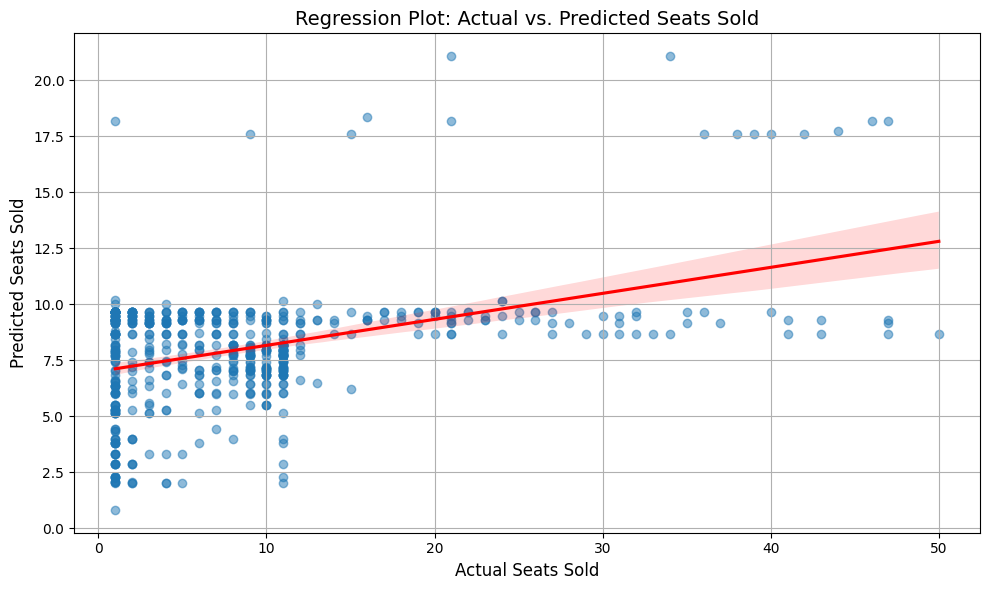

In [67]:
# Step 8: Create the regression plot
plt.figure(figsize=(10, 6))
sns.regplot( x=y_test, y=y_pred, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel("Actual Seats Sold", fontsize=12)
plt.ylabel("Predicted Seats Sold", fontsize=12)
plt.title("Regression Plot: Actual vs. Predicted Seats Sold", fontsize=14)
plt.grid(True)
plt.tight_layout()

In [68]:
## Conclusion

#The model was able to predict transport demand based on available features. This can help in better planning of bus capacity.